In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("d:\\UAH GO CHARGERS\\Spring 26\\MSC450\\Midterm\\housing_train.csv")
data.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,price
0,4306.971093,4,2,3,yes,no,no,no,yes,2,23807.62253
1,4732.863826,4,4,4,yes,no,no,no,yes,3,46173.57355
2,4989.989980,3,2,2,yes,no,yes,no,no,2,25491.22063
3,4330.127019,4,2,2,yes,no,yes,no,yes,3,18941.80522
4,4306.971093,4,1,2,yes,yes,yes,no,yes,2,17582.99123


In [18]:
#Converting variables into dummy variables

In [19]:
mainroad = pd.get_dummies(data.mainroad)
mainroad = mainroad.rename(columns = {"yes":"mainroad"}).iloc[:,1:].astype(int)
guestroom = pd.get_dummies(data.guestroom)
guestroom = guestroom.rename(columns = {"yes":"guestroom"}).iloc[:,1:].astype(int)
basement = pd.get_dummies(data.basement)
basement = basement.rename(columns = {"yes":"basement"}).iloc[:,1:].astype(int)
hotwaterheating = pd.get_dummies(data.hotwaterheating)
hotwaterheating = hotwaterheating.rename(columns = {"yes":"hotwaterheating"}).iloc[:,1:].astype(int)
airconditioning = pd.get_dummies(data.airconditioning)
airconditioning = airconditioning.rename(columns = {"yes":"airconditioning"}).iloc[:,1:].astype(int)

data1 = pd.concat([data.iloc[:,:4],mainroad, guestroom, basement, hotwaterheating, airconditioning,data.iloc[:,-2:]],axis=1)
data1.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,price
0,4306.971093,4,2,3,1,0,0,0,1,2,23807.62253
1,4732.863826,4,4,4,1,0,0,0,1,3,46173.57355
2,4989.989980,3,2,2,1,0,1,0,0,2,25491.22063
3,4330.127019,4,2,2,1,0,1,0,1,3,18941.80522
4,4306.971093,4,1,2,1,1,1,0,1,2,17582.99123


Text(0.5, 1.0, 'Number of parking')

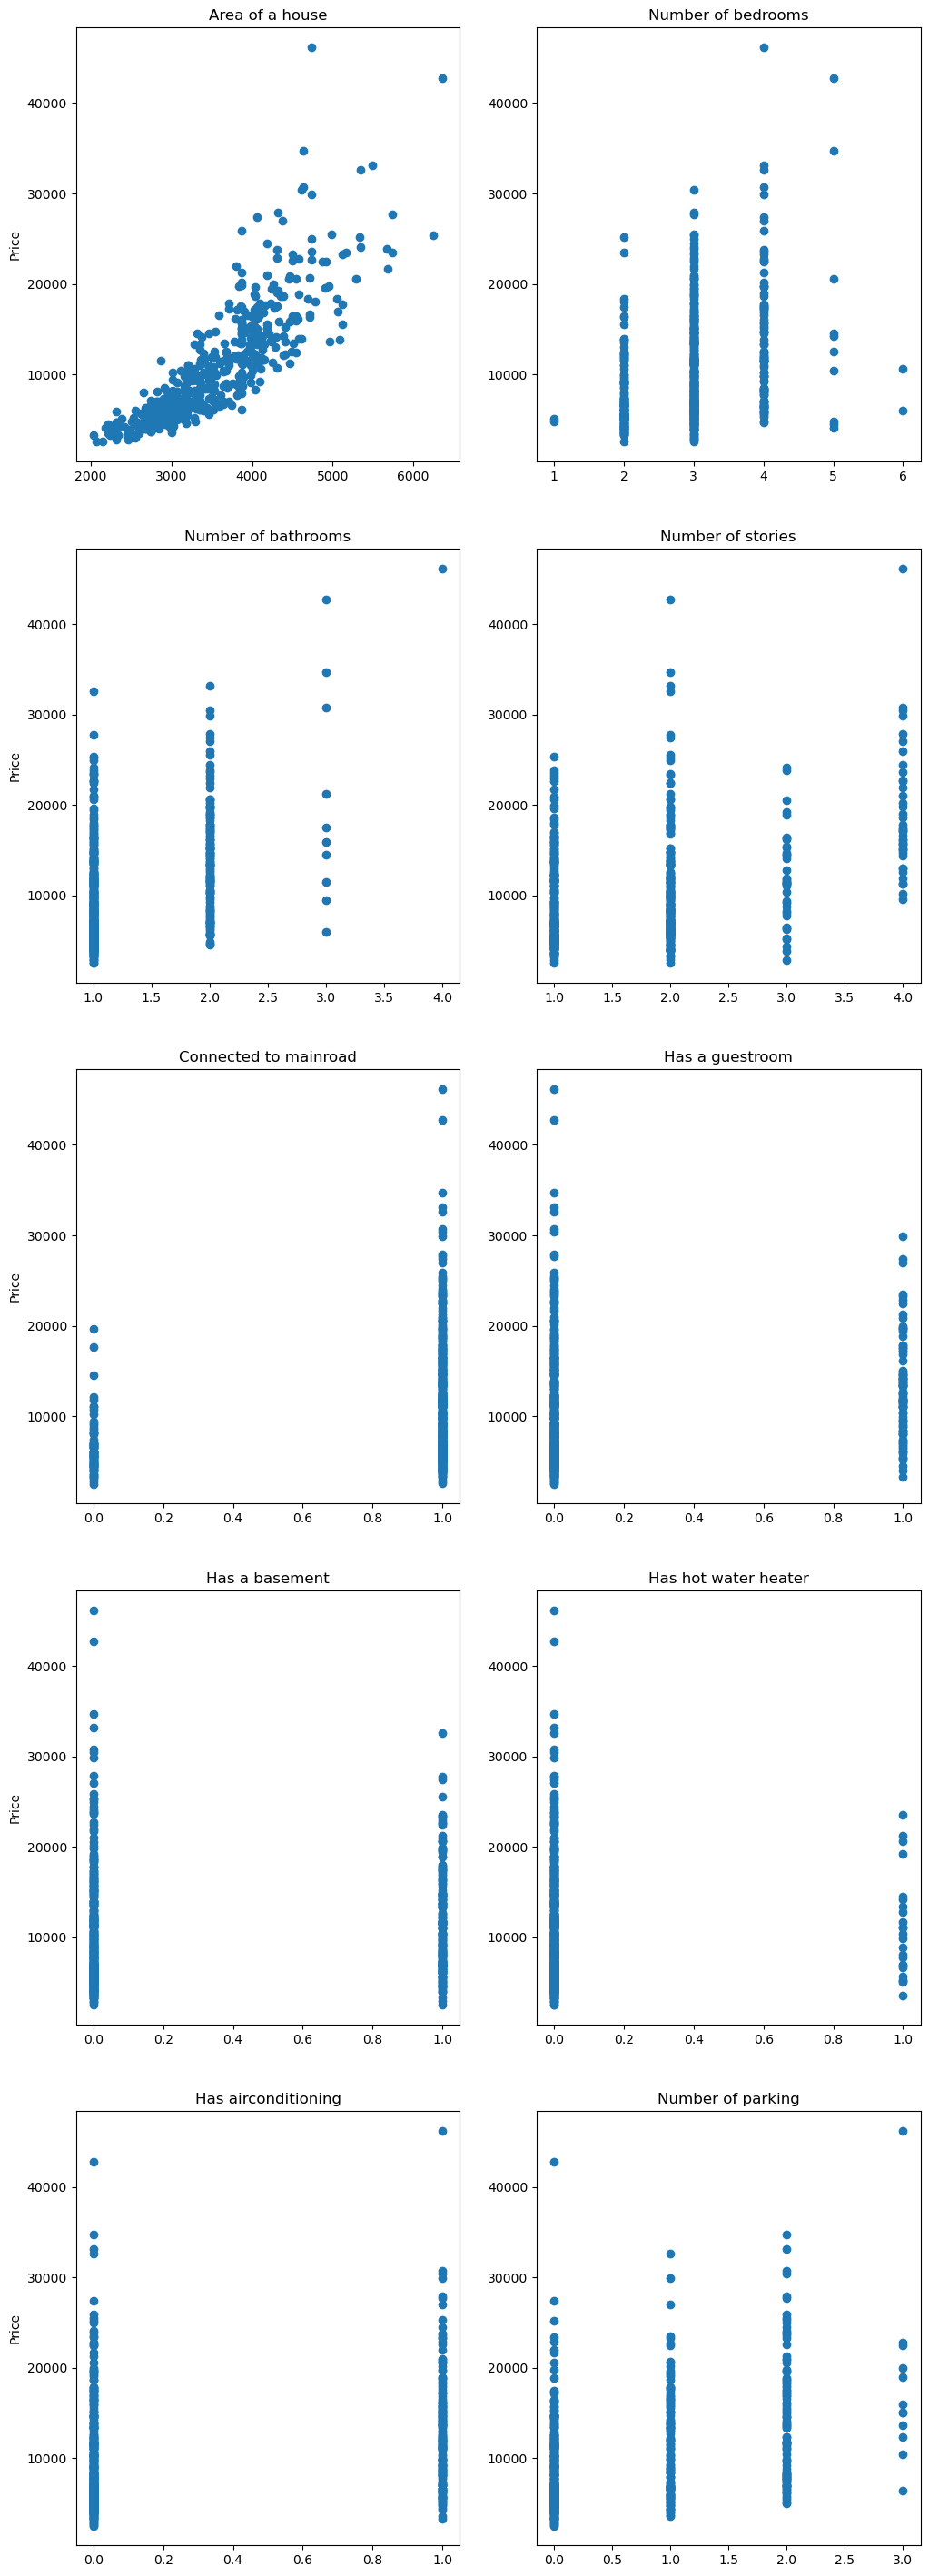

In [20]:
figure, axis = plt.subplots(5,2, figsize=(12,36))
axis[0,0].scatter(data1.area, data1.price)
axis[0,0].set_title("Area of a house")
axis[0,0].set_ylabel("Price")
axis[0,1].scatter(data1.bedrooms, data1.price)
axis[0,1].set_title("Number of bedrooms")

axis[1,0].scatter(data1.bathrooms, data1.price)
axis[1,0].set_title("Number of bathrooms")
axis[1,0].set_ylabel("Price")
axis[1,1].scatter(data1.stories, data1.price)
axis[1,1].set_title("Number of stories")

axis[2,0].scatter(data1.mainroad, data1.price)
axis[2,0].set_ylabel("Price")
axis[2,0].set_title("Connected to mainroad")
axis[2,1].scatter(data1.guestroom, data1.price)
axis[2,1].set_title("Has a guestroom")

axis[3,0].scatter(data1.basement, data1.price)
axis[3,0].set_ylabel("Price")
axis[3,0].set_title("Has a basement")
axis[3,1].scatter(data1.hotwaterheating, data1.price)
axis[3,1].set_title("Has hot water heater")

axis[4,0].scatter(data1.airconditioning, data1.price)
axis[4,0].set_ylabel("Price")
axis[4,0].set_title("Has airconditioning")
axis[4,1].scatter(data1.parking, data1.price)
axis[4,1].set_title("Number of parking")

In [21]:
import statsmodels.api as sm
ols = sm.OLS(data1.iloc[:,10],sm.add_constant(data1.iloc[:,:10]))
lm = ols.fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     346.4
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          7.67e-225
Time:                        22:13:21   Log-Likelihood:                -4935.6
No. Observations:                 540   AIC:                             9893.
Df Residuals:                     529   BIC:                             9940.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            -1.99e+04    631.814    -

Text(0.5, 1.0, 'Residuals vs. Fitted values')

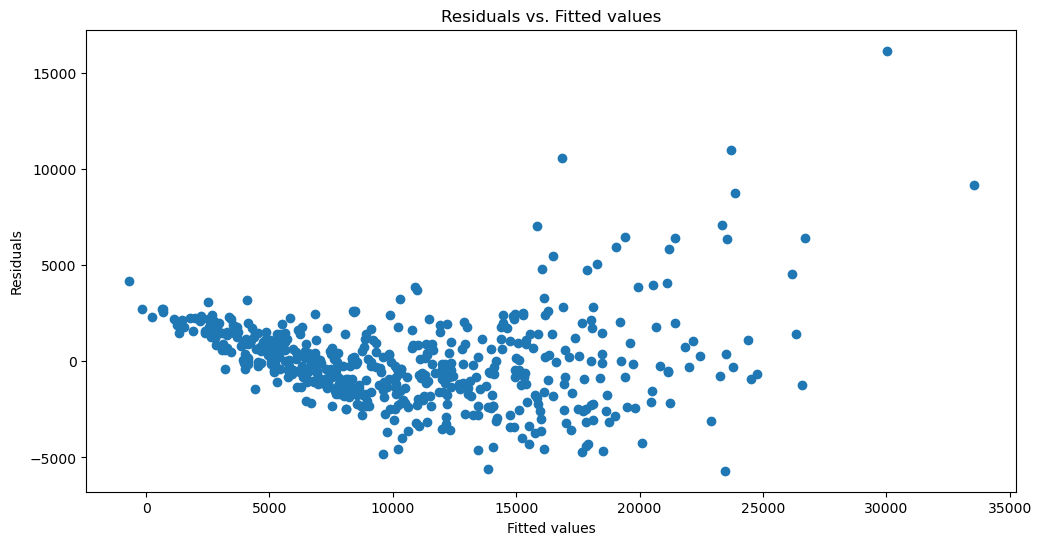

In [22]:
fitted_y = lm.fittedvalues
residual = lm.resid
plt.figure(figsize=(12,6))
plt.scatter(fitted_y, residual)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted values")

Text(0, 0.5, 'Frequency')

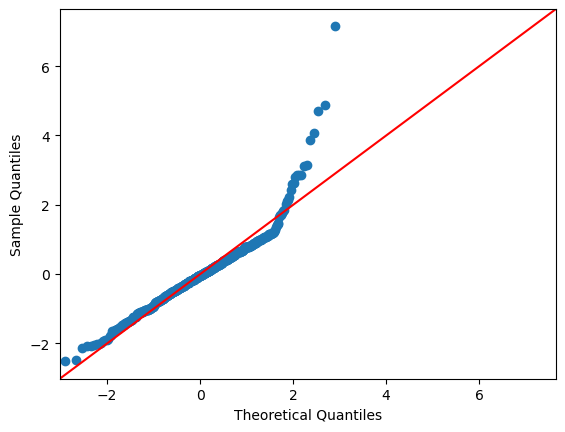

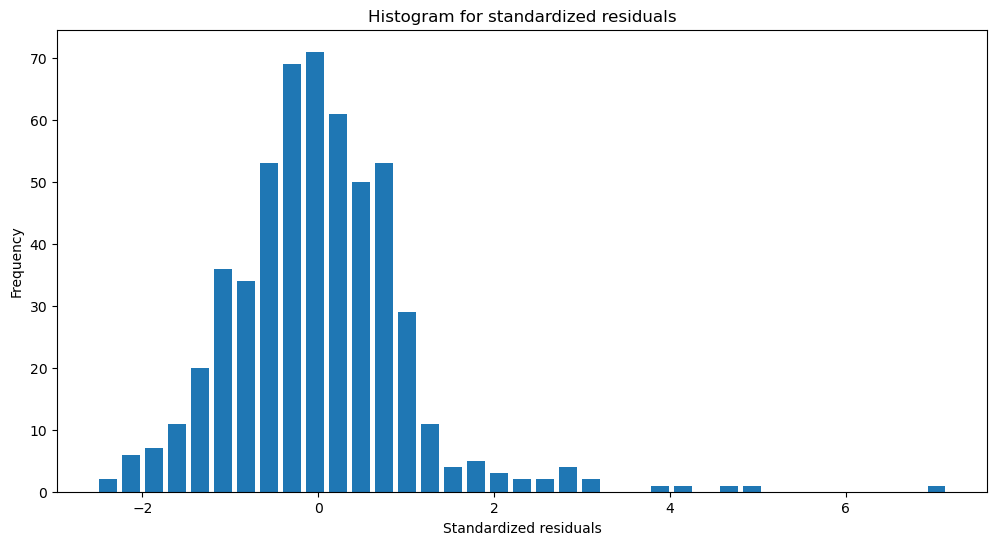

In [23]:
from sklearn.preprocessing import scale
residual_norm = scale(residual)
sm.qqplot(residual_norm, line = '45')
plt.figure(figsize=(12,6))
plt.hist(x=residual_norm, bins='auto', rwidth = 0.75)
plt.title("Histogram for standardized residuals")
plt.xlabel("Standardized residuals")
plt.ylabel("Frequency")

In [24]:
#Model correction

In [25]:
price = np.log(data.iloc[:,10:])
price = price.rename(columns={"price":"log_price"})
data2 = pd.concat([data1.iloc[:,0:10], price], axis = 1)
data2.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,log_price
0,4306.971093,4,2,3,1,0,0,0,1,2,10.077761
1,4732.863826,4,4,4,1,0,0,0,1,3,10.740163
2,4989.989980,3,2,2,1,0,1,0,0,2,10.146089
3,4330.127019,4,2,2,1,0,1,0,1,3,9.849127
4,4306.971093,4,1,2,1,1,1,0,1,2,9.774687


In [26]:
ols2 = sm.OLS(data2.iloc[:,10], sm.add_constant(data2.iloc[:,0:10]))
lm2 = ols2.fit()
print(lm2.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     537.2
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          1.26e-269
Time:                        22:13:22   Log-Likelihood:                 218.62
No. Observations:                 540   AIC:                            -415.2
Df Residuals:                     529   BIC:                            -368.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               6.3858      0.045    1

Text(0.5, 1.0, 'Residuals vs. Fitted values')

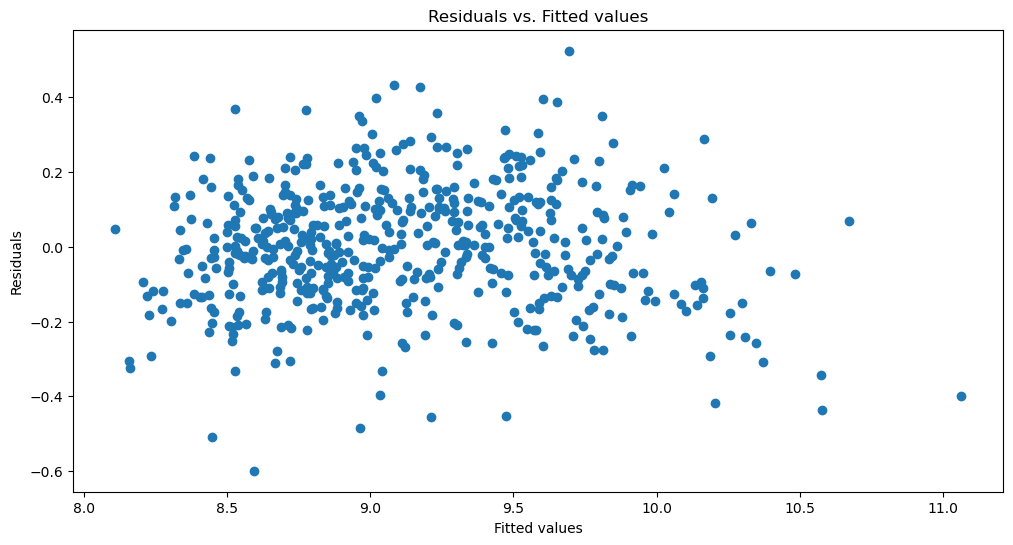

In [27]:
fitted_y2 = lm2.fittedvalues
residual2 = lm2.resid
plt.figure(figsize=(12,6))
plt.scatter(fitted_y2, residual2)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted values")

Text(0, 0.5, 'Frequency')

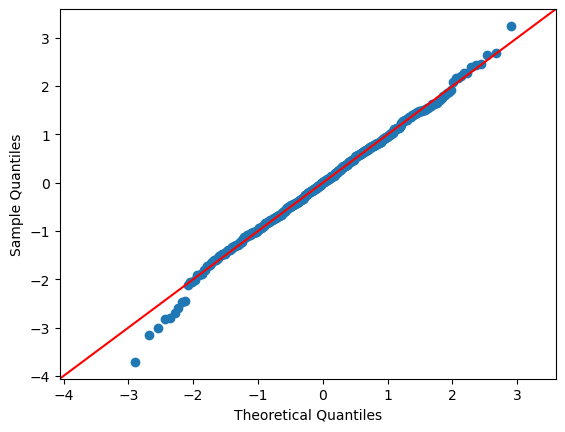

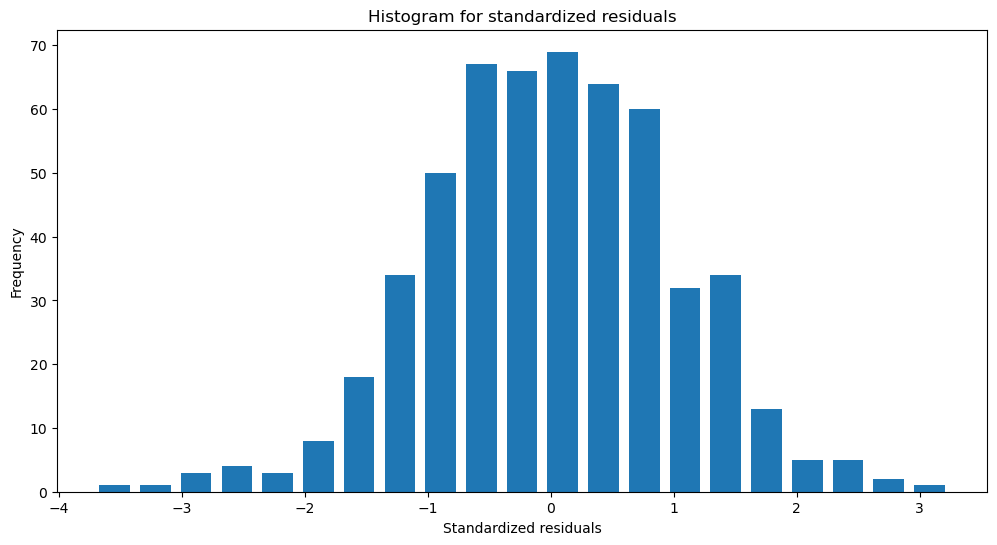

In [28]:
from sklearn.preprocessing import scale
residual_norm2 = scale(residual2)
sm.qqplot(residual_norm2, line = '45')
plt.figure(figsize=(12,6))
plt.hist(x=residual_norm2, bins='auto', rwidth = 0.75)
plt.title("Histogram for standardized residuals")
plt.xlabel("Standardized residuals")
plt.ylabel("Frequency")

In [29]:
#Feature selection

In [30]:
import itertools
def fit_lm(feature_set):
    ols = sm.OLS(data2.log_price, sm.add_constant(data2[list(feature_set)]))
    lm = ols.fit()
    RSS = ((lm.predict(sm.add_constant(data2[list(feature_set)])) - data2.log_price) ** 2).sum()
    rsquared_adj = lm.rsquared_adj
    AIC = lm.aic
    BIC = lm.bic
    return {"model":lm, "RSS":RSS,"Rsquare_adj": rsquared_adj,"AIC":AIC,"BIC":BIC}
    
def getbest(k):
    result = []
    for combo in itertools.combinations(data2.columns[:10], k):
        result.append(fit_lm(combo))
    models = pd.DataFrame(result)
    best_model = models.loc[models["BIC"].argmin()]
    return best_model

In [31]:
import time
remain = list(data2.columns[:10])
picked = list()
model_best = pd.DataFrame(columns=["model","RSS","Rsquared_adj","AIC","BIC"])
start = time.time()
for i in range(1,len(data2.columns)):
    best_BIC = np.inf
    for combo in itertools.combinations(remain,1):
        BIC = fit_lm(list(combo) + picked)["BIC"]
        if BIC < best_BIC:
            best_BIC = BIC
            best_feature = combo[0]
            model_best.loc[i] = fit_lm(list(combo) + picked)
    picked.append(best_feature)
    remain.remove(best_feature)

end = time.time()
best_index = model_best["BIC"].idxmin()
lm3 = model_best.loc[best_index,"model"]
print(model_best)
print("Foward selection take: ", end-start, "seconds")
print(lm3.summary())

                                                model        RSS  \
1   <statsmodels.regression.linear_model.Regressio...  35.086933   
2   <statsmodels.regression.linear_model.Regressio...  23.920680   
3   <statsmodels.regression.linear_model.Regressio...  18.937242   
4   <statsmodels.regression.linear_model.Regressio...  15.758463   
5   <statsmodels.regression.linear_model.Regressio...  14.445373   
6   <statsmodels.regression.linear_model.Regressio...  14.154952   
7   <statsmodels.regression.linear_model.Regressio...  14.115968   
8   <statsmodels.regression.linear_model.Regressio...  14.096428   
9   <statsmodels.regression.linear_model.Regressio...  14.082198   
10  <statsmodels.regression.linear_model.Regressio...  14.069106   

    Rsquared_adj         AIC         BIC  
1            NaN   60.233821   68.816959  
2            NaN -144.632304 -131.757597  
3            NaN -268.783283 -251.617007  
4            NaN -366.009830 -344.551985  
5            NaN -410.991690 -385.24

Text(0.5, 1.0, 'Residuals vs. Fitted values')

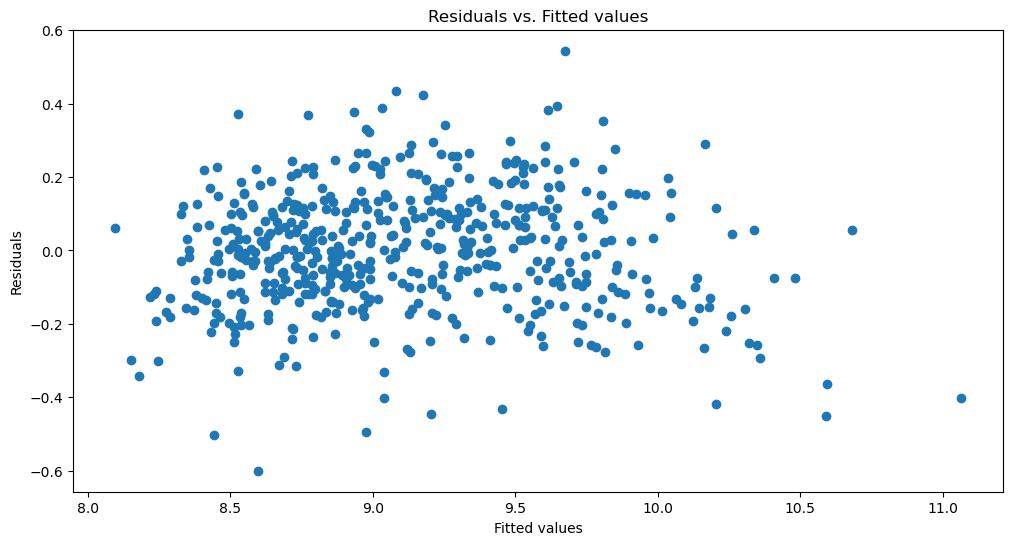

In [32]:
residual3 = lm3.resid
fitted_y3 = lm3.fittedvalues
plt.figure(figsize=(12,6))
plt.scatter(fitted_y3, residual3)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted values")

Text(0, 0.5, 'Frequency')

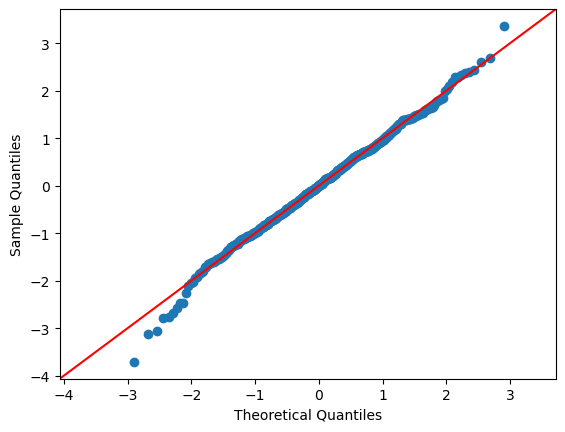

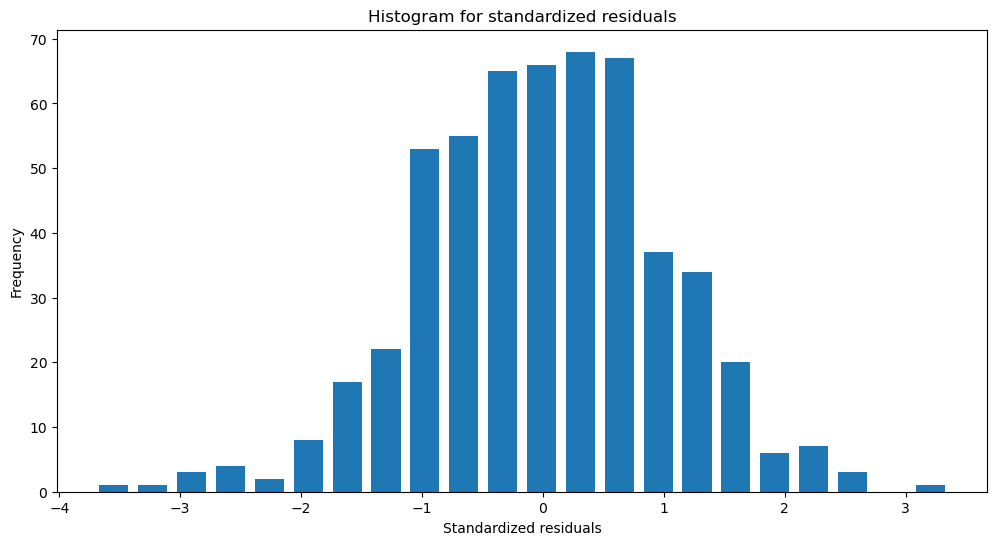

In [33]:
from sklearn.preprocessing import scale
residual_norm3 = scale(residual3)
sm.qqplot(residual_norm3, line = '45')
plt.figure(figsize=(12,6))
plt.hist(x=residual_norm3, bins='auto', rwidth = 0.75)
plt.title("Histogram for standardized residuals")
plt.xlabel("Standardized residuals")
plt.ylabel("Frequency")

In [34]:
#Check outliers

In [72]:
data3 = pd.concat([data2.iloc[:,0:4], data2.iloc[:,6],data2.iloc[:,9:]],axis=1)
data3.head()

,area,bedrooms,bathrooms,stories,basement,parking,log_price
0,4306.971093,4,2,3,0,2,10.077761
1,4732.863826,4,4,4,0,3,10.740163
2,4989.989980,3,2,2,1,2,10.146089
3,4330.127019,4,2,2,1,3,9.849127
4,4306.971093,4,1,2,1,2,9.774687


In [36]:
Q1 = np.quantile(residual_norm3, 0.25)
Q3 = np.quantile(residual_norm3, 0.75)
iqr = Q3 - Q1
data3[(residual_norm3 < Q1-1.5*iqr) | (residual_norm3 > Q3+1.5*iqr)]

,area,bedrooms,bathrooms,stories,basement,parking,log_price
120,6244.997998,3,1,1,0,2,10.139901
145,3583.294573,3,1,2,1,0,8.756768
157,4062.019202,4,2,2,1,0,10.219759
406,2315.707235,3,1,3,0,0,7.936753
407,2554.407955,3,1,2,1,0,7.996794
469,3298.484500,4,1,2,0,1,8.478565


In [49]:
data4 = data3[(residual_norm3 > Q1-1.5*iqr) & (residual_norm3 < Q3+1.5*iqr)]
data4

,area,bedrooms,bathrooms,stories,basement,parking,log_price
0,4306.971093,4,2,3,0,2,10.077761
1,4732.863826,4,4,4,0,3,10.740163
2,4989.989980,3,2,2,1,2,10.146089
3,4330.127019,4,2,2,1,3,9.849127
4,4306.971093,4,1,2,1,2,9.774687
...,...,...,...,...,...,...,...
535,2738.612788,2,1,1,1,2,8.534901
536,2449.489743,3,1,1,0,0,8.044885
537,3008.321791,2,1,1,0,0,8.561375
538,2697.220792,3,1,1,0,0,8.448412


In [38]:
ols4 = sm.OLS(data4.iloc[:,6],sm.add_constant(data4.iloc[:,:6]))
lm4 = ols4.fit()
print(lm4.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     970.4
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          4.46e-281
Time:                        22:13:24   Log-Likelihood:                 243.18
No. Observations:                 534   AIC:                            -472.4
Df Residuals:                     527   BIC:                            -442.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.4023      0.041    154.283      0.0

Text(0, 0.5, 'Residuals')

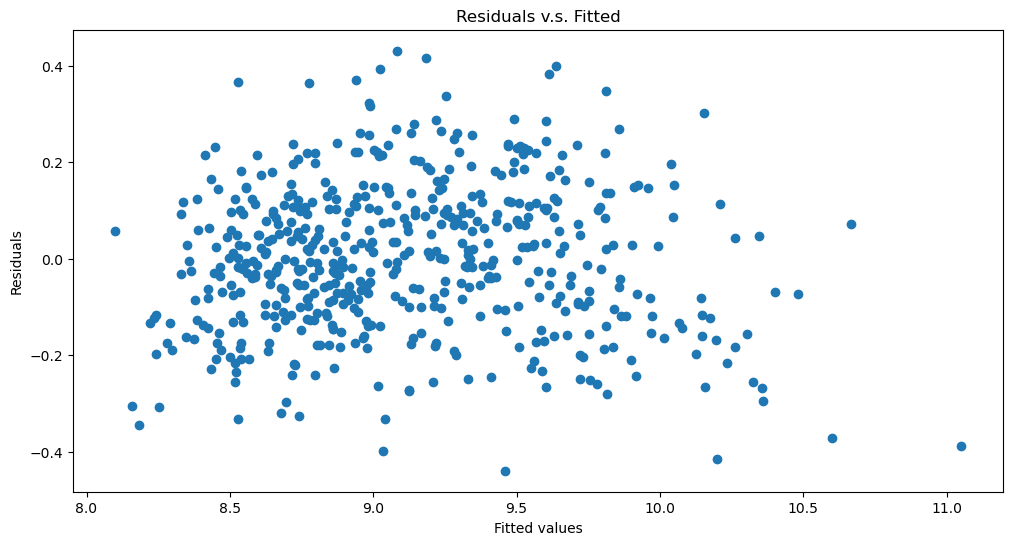

In [39]:
fitted_y4 = lm4.fittedvalues
residual4 = lm4.resid
plt.figure(figsize=(12,6))
plt.scatter(fitted_y4,residual4)
plt.title('Residuals v.s. Fitted')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')

Text(0, 0.5, 'Frequency')

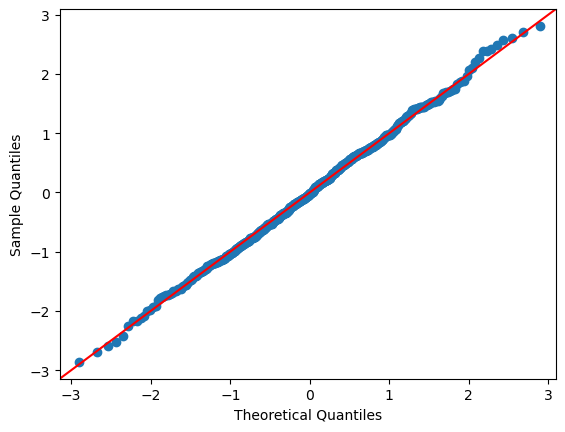

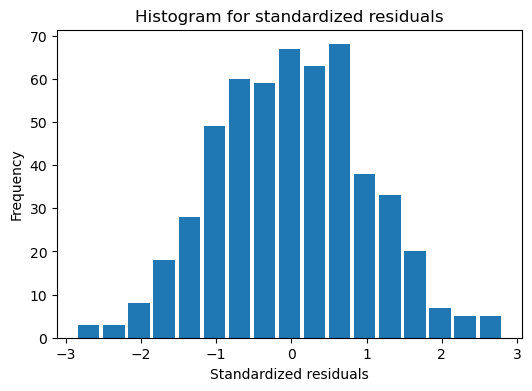

In [40]:
from sklearn.preprocessing import scale
residual4 = lm4.resid
residual_norm4 = scale(residual4)
sm.qqplot(residual_norm4, line='45')
plt.figure(figsize=(6,4))
plt.hist(x=residual_norm4, bins='auto', rwidth=0.85)
plt.title('Histogram for standardized residuals')
plt.xlabel('Standardized residuals')
plt.ylabel('Frequency')

In [41]:
test = pd.read_csv("d:\\UAH GO CHARGERS\\Spring 26\\MSC450\\Midterm\\housing_test.csv")
test.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,price
0,3391.164992,3,2,2,yes,yes,no,no,yes,2,13648.38942
1,4006.245125,3,2,2,yes,no,no,no,yes,1,17305.14429
2,3286.335345,3,1,2,no,no,yes,yes,no,2,10205.51922
3,4229.361654,3,2,1,yes,yes,yes,no,yes,2,17321.41596
4,4486.089611,3,1,1,yes,yes,yes,no,yes,1,15862.92477


In [42]:
mainroad = pd.get_dummies(test.mainroad)
mainroad = mainroad.rename(columns = {"yes":"mainroad"}).iloc[:,1:].astype(int)
guestroom = pd.get_dummies(test.guestroom)
guestroom = guestroom.rename(columns = {"yes":"guestroom"}).iloc[:,1:].astype(int)
basement = pd.get_dummies(test.basement)
basement = basement.rename(columns = {"yes":"basement"}).iloc[:,1:].astype(int)
hotwaterheating = pd.get_dummies(test.hotwaterheating)
hotwaterheating = hotwaterheating.rename(columns = {"yes":"hotwaterheating"}).iloc[:,1:].astype(int)
airconditioning = pd.get_dummies(test.airconditioning)
airconditioning = airconditioning.rename(columns = {"yes":"airconditioning"}).iloc[:,1:].astype(int)

test1 = pd.concat([test.iloc[:,:4],mainroad, guestroom, basement, hotwaterheating, airconditioning,test.iloc[:,-2:]],axis=1)
test1.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,price
0,3391.164992,3,2,2,1,1,0,0,1,2,13648.38942
1,4006.245125,3,2,2,1,0,0,0,1,1,17305.14429
2,3286.335345,3,1,2,0,0,1,1,0,2,10205.51922
3,4229.361654,3,2,1,1,1,1,0,1,2,17321.41596
4,4486.089611,3,1,1,1,1,1,0,1,1,15862.92477


In [78]:
from sklearn.metrics import mean_squared_error

x_test = test1.iloc[:, [0,1,2,3,6,9]]
x_test = sm.add_constant(x_test, has_constant = "add")

y_test = test1.iloc[:,10]

y_pred = np.exp(lm4.predict(x_test))

mse = mean_squared_error(y_test, y_pred)
print(f"The mean squared error is: {mse}")


The mean squared error is: 5970016.947270194
